# 스텝 수 `T` 를 줄이면 꼬리가 살아나는가

## 0. 셋업

In [18]:
import os, sys, time

sys.path.insert(0, os.path.abspath("."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq

import t_diffusion as td

import matplotlib.font_manager as fm
_have = {f.name for f in fm.fontManager.ttflist}
KFONT = next((f for f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"]
              if f in _have), None)
if KFONT:
    plt.rcParams["font.family"] = KFONT
plt.rcParams["axes.unicode_minus"] = False

from matplotlib.ticker import FuncFormatter
_PLAIN = FuncFormatter(lambda v, _: f"{v:g}")

def _minor(v, _):
    if v == 0:
        return ""
    m = abs(v) / 10 ** np.floor(np.log10(abs(v)))
    return f"{v:g}" if round(m) in (2, 3, 5) else ""

def plain_ticks(ax, axis="y"):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_formatter(_PLAIN)
    a.set_minor_formatter(FuncFormatter(_minor))

NU_DATA, LOC, SCALE = 3.0, 0.0, 1.0
N_TOTAL, N_TRAIN = 50000, 10000
BATCH, LR, HIDDEN = 128, 1e-3, 128
BETA_START = 1e-4

T_LIST = [1000, 500, 250, 100, 20]  # 스윕할 스텝 수
NU_LIST = [3.0, 500.0] # nu=500 은 대조군 (s_t 가 1 에 붙박이)
SEEDS = [0]
STEPS = 20000
N_SAMPLE = 20000
CACHE = "models_cache_T"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(CACHE, exist_ok=True)
print(f"device = {DEVICE} | T = {T_LIST} | nu = {NU_LIST} | seeds = {SEEDS}")
print(f"학습 횟수 = {len(T_LIST) * len(NU_LIST) * len(SEEDS)}회  (steps={STEPS})")

device = cuda | T = [1000, 500, 250, 100, 20] | nu = [3.0, 500.0] | seeds = [0]
학습 횟수 = 10회  (steps=20000)


## 1. `beta_end` 를 맞춘다

In [19]:
def abar_T(T, beta_end, beta_start=BETA_START):
    return float(np.cumprod(1.0 - np.linspace(beta_start, beta_end, T))[-1])

TARGET = abar_T(1000, 0.02)          # 기준: 원래 설정

def beta_end_for(T):
    if T == 1000:
        return 0.02
    return brentq(lambda be: abar_T(T, be) - TARGET, 0.02, 0.9)

BE = {T: beta_end_for(T) for T in T_LIST}

print(f"목표 abar_T = {TARGET:.4e}   (T=1000, beta_end=0.02 기준)\n")
print(f"{'T':>6}{'beta_end':>11}{'abar_T':>13}{'mu_T':>9}{'sigma_T/mu_T':>14}"
      f"{'sigmabar^2 최대':>16}{'스텝당 노이즈 std':>18}")
print("-" * 88)
for T in T_LIST:
    sch = td.Schedule(T, beta_start=BETA_START, beta_end=BE[T])
    mu, sg = float(sch.mu[-1]), float(sch.sigma[-1])
    sb2 = sch.sigmabar2.numpy()
    print(f"{T:6d}{BE[T]:11.4f}{abar_T(T, BE[T]):13.4e}{mu:9.4f}{sg / mu:14.1f}"
          f"{sb2.max():16.4f}{np.sqrt(sb2.max()):18.4f}")

목표 abar_T = 4.0358e-05   (T=1000, beta_end=0.02 기준)

     T   beta_end       abar_T     mu_T  sigma_T/mu_T   sigmabar^2 최대       스텝당 노이즈 std
----------------------------------------------------------------------------------------
  1000     0.0200   4.0358e-05   0.0064         157.4          0.0200            0.1414
   500     0.0398   4.0358e-05   0.0064         157.4          0.0398            0.1996
   250     0.0787   4.0358e-05   0.0064         157.4          0.0787            0.2805
   100     0.1890   4.0358e-05   0.0064         157.4          0.1890            0.4347
    20     0.7144   4.0358e-05   0.0064         157.4          0.7144            0.8452

abar_T 가 모두 같으면 통제 성공. sigmabar^2 는 T 가 작을수록 커진다 -- 의도한 바다


## 2. 데이터와 평가 지표

In [20]:
def make_data(seed=0):
    rng = np.random.default_rng(seed)
    pool = stats.t.rvs(df=NU_DATA, loc=LOC, scale=SCALE, size=N_TOTAL, random_state=rng)
    idx = rng.permutation(N_TOTAL)
    return pool[idx[:N_TRAIN]], pool[idx[N_TRAIN:]]

train_np, held = make_data(0)
x0 = torch.tensor(train_np, dtype=torch.float32).unsqueeze(-1)
print(f"data ~ t(nu={NU_DATA:g}) | train {len(train_np)} | held {len(held)}")

def evaluate(g, held):
    g = np.asarray(g, dtype=np.float64)
    out = {"n_nonfinite": int((~np.isfinite(g)).sum())}
    g = g[np.isfinite(g)]
    a = np.abs(g)
    srt = np.sort(a)[::-1]
    k = max(10, int(0.1 * len(srt)))
    out["P5"] = float(np.mean(a > 5))                      # 가장 안정적인 꼬리 지표
    out["P10"] = float(np.mean(a > 10))
    out["hill"] = float(1.0 / np.mean(np.log(srt[:k] / srt[k])))
    out["mle_df"] = float(stats.t.fit(g)[0])
    out["iqr"] = float(np.subtract(*np.percentile(g, [75, 25])))
    out["q999"] = float(np.quantile(a, 0.999))             # 불안정 -- 참고용
    out["ad"] = float(stats.anderson_ksamp([g, held]).statistic)
    return out

TRUE = {"P5": float(2 * stats.t.sf(5, NU_DATA)),
        "P10": float(2 * stats.t.sf(10, NU_DATA)),
        "hill": NU_DATA, "mle_df": NU_DATA,
        "iqr": float(2 * stats.t.ppf(0.75, NU_DATA)),
        "q999": float(stats.t.ppf(0.9995, NU_DATA)), "ad": 0.0}

_brng = np.random.default_rng(12345)
BASE = evaluate(_brng.choice(train_np, N_SAMPLE, replace=True), held)   # 암기 기준선

KEYS = ["P5", "P10", "hill", "mle_df", "iqr", "q999", "ad"]
HDR = f"{'':>22}" + "".join(f"{k:>9}" for k in KEYS)
print()
print(HDR)
print(f"{'참값 t(3)':>22}" + "".join(f"{TRUE[k]:9.4f}" for k in KEYS))
print(f"{'학습셋 복원추출':>22}" + "".join(f"{BASE[k]:9.4f}" for k in KEYS))

data ~ t(nu=3) | train 10000 | held 40000

                             P5      P10     hill   mle_df      iqr     q999       ad
               참값 t(3)   0.0154   0.0021   3.0000   3.0000   1.5298  12.9240   0.0000
              학습셋 복원추출   0.0169   0.0020   2.4119   3.0451   1.5760  11.5583   6.9796

생성 결과가 '학습셋 복원추출' 을 못 넘으면 암기와 구분되지 않는다


## 3. 학습과 샘플링

In [21]:
def get_model(nu, T, seed):
    path = f"{CACHE}/nu{nu:g}_T{T}_be{BE[T]:.4f}_s{STEPS}_seed{seed}.pt"
    if os.path.exists(path):
        m = td.Denoiser(d=1, hidden=HIDDEN, T=T).to(DEVICE)
        m.load_state_dict(torch.load(path, map_location=DEVICE))
        m.eval()
        return m, td.Schedule(T, beta_start=BETA_START, beta_end=BE[T], device=DEVICE)
    t0 = time.time()
    print(f"  nu={nu:<5g} T={T:<5d} seed={seed}  학습 ... ", end="", flush=True)
    m, sch = td.train(x0, nu, T=T, steps=STEPS, batch=BATCH, lr=LR, hidden=HIDDEN,
                      device=DEVICE, seed=seed, beta_end=BE[T])
    torch.save(m.state_dict(), path)
    print(f"{time.time() - t0:.1f}s")
    return m, sch

RES, GEN = {}, {}          # GEN 은 생존함수 그림에 쓴다 (표본당 20000 x 8바이트 = 0.16MB)
t_all = time.time()
for nu in NU_LIST:
    for T in T_LIST:
        for seed in SEEDS:
            m, sch = get_model(nu, T, seed)
            g = td.sample(m, sch, nu, n=N_SAMPLE, device=DEVICE, seed=seed).numpy()
            g = np.asarray(g, dtype=np.float64)
            RES[(nu, T, seed)] = evaluate(g, held)
            GEN[(nu, T, seed)] = g
print(f"전체 {time.time() - t_all:.0f}s")

전체 9s


## 4. 결과

In [22]:
def agg(nu, T, key):
    v = np.array([RES[(nu, T, s)][key] for s in SEEDS])
    return v.mean(), v.std()

print(f"{'nu':>5}{'T':>6} | " + "".join(f"{k:>17}" for k in ["P5", "P10", "hill", "iqr"]))
print("-" * 80)
for nu in NU_LIST:
    for T in T_LIST:
        row = f"{nu:5g}{T:6d} | "
        for k in ["P5", "P10", "hill", "iqr"]:
            m, sd = agg(nu, T, k)
            row += f"{m:11.4f}+-{sd:<4.3f}"
        print(row)
    print("-" * 80)
print(f"{'참값':>11} | " + "".join(f"{TRUE[k]:11.4f}{'':6}" for k in ["P5", "P10", "hill", "iqr"]))
print(f"{'학습셋':>11} | " + "".join(f"{BASE[k]:11.4f}{'':6}" for k in ["P5", "P10", "hill", "iqr"]))

   nu     T |                P5              P10             hill              iqr
--------------------------------------------------------------------------------
    3  1000 |      0.0141+-0.000     0.0016+-0.000     2.0454+-0.000     1.2160+-0.000
    3   500 |      0.0073+-0.000     0.0007+-0.000     2.5417+-0.000     1.2878+-0.000
    3   250 |      0.0120+-0.000     0.0001+-0.000     2.3417+-0.000     1.3425+-0.000
    3   100 |      0.0085+-0.000     0.0006+-0.000     2.4899+-0.000     1.3123+-0.000
    3    20 |      0.0053+-0.000     0.0006+-0.000     2.5261+-0.000     1.1795+-0.000
--------------------------------------------------------------------------------
  500  1000 |      0.0179+-0.000     0.0023+-0.000     2.5811+-0.000     1.5327+-0.000
  500   500 |      0.0164+-0.000     0.0018+-0.000     2.4262+-0.000     1.4097+-0.000
  500   250 |      0.0176+-0.000     0.0019+-0.000     2.5783+-0.000     1.4947+-0.000
  500   100 |      0.0140+-0.000     0.0016+-0.000     2.48

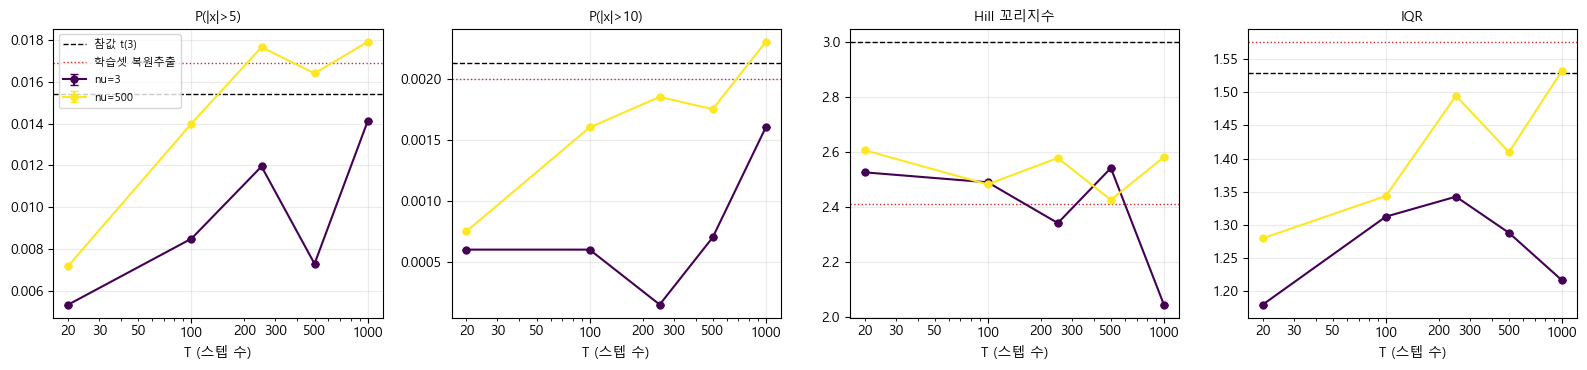

In [23]:
SHOW = [("P5", "P(|x|>5)"), ("P10", "P(|x|>10)"), ("hill", "Hill 꼬리지수"), ("iqr", "IQR")]
fig, axes = plt.subplots(1, len(SHOW), figsize=(4.0 * len(SHOW), 3.8))
cm = plt.get_cmap("viridis")
for ax, (k, lab) in zip(axes, SHOW):
    for j, nu in enumerate(NU_LIST):
        m = np.array([agg(nu, T, k)[0] for T in T_LIST])
        sd = np.array([agg(nu, T, k)[1] for T in T_LIST])
        col = cm(j / max(len(NU_LIST) - 1, 1))
        ax.errorbar(T_LIST, m, yerr=sd, fmt="o-", ms=5, capsize=3,
                    color=col, label=f"nu={nu:g}")
    ax.axhline(TRUE[k], color="k", lw=1.0, ls="--", label="참값 t(3)")
    ax.axhline(BASE[k], color="tab:red", lw=1.0, ls=":", label="학습셋 복원추출")
    ax.set_xscale("log")
    plain_ticks(ax, "x")
    ax.set_xlabel("T (스텝 수)")
    ax.set_title(lab, fontsize=10)
    ax.grid(alpha=0.25)
    if ax is axes[0]:
        ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5. 꼬리 생존함수

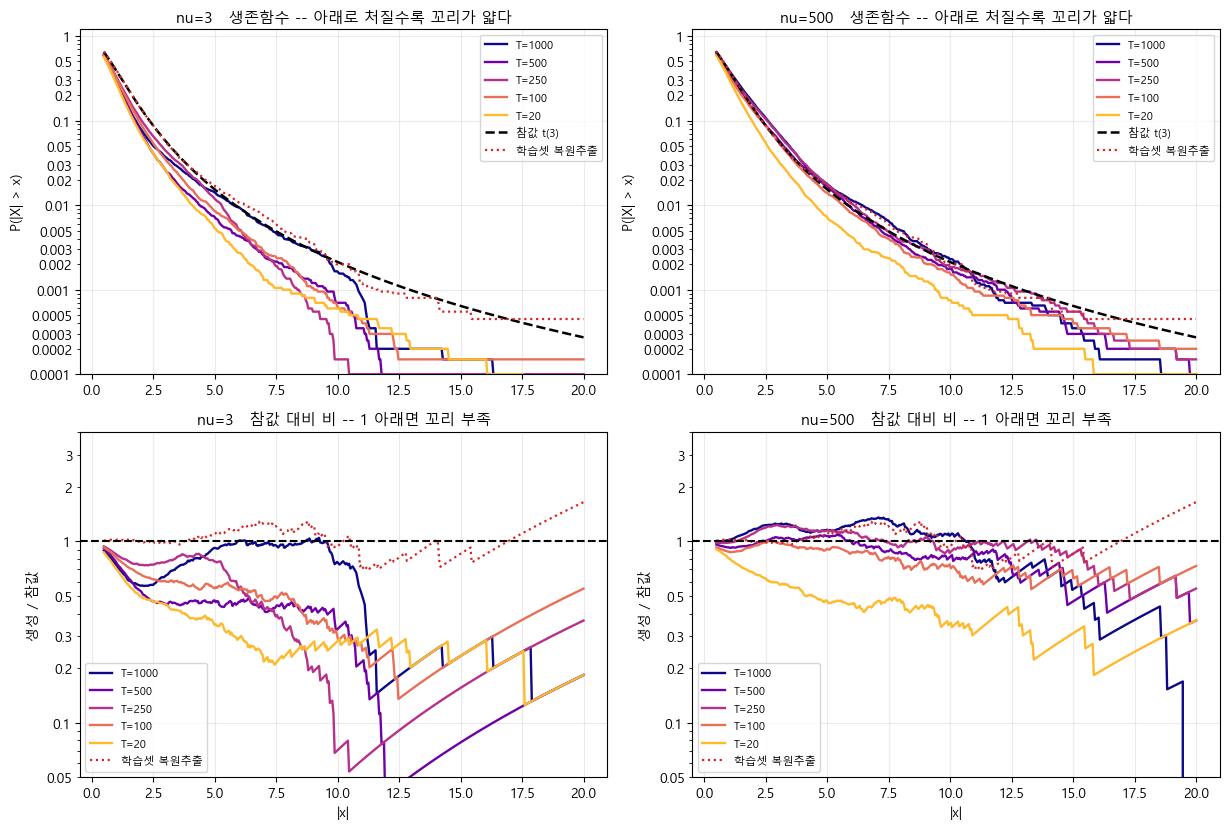

In [24]:
SEED0 = SEEDS[0]
XS = np.linspace(0.5, 20, 400)
TRU = 2 * stats.t.sf(XS, NU_DATA)
_bs = np.random.default_rng(12345).choice(train_np, N_SAMPLE, replace=True)
BASE_S = np.array([np.mean(np.abs(_bs) > v) for v in XS])

cmT = plt.get_cmap("plasma")
COLT = {T: cmT(j / max(len(T_LIST) - 1, 1) * 0.85) for j, T in enumerate(T_LIST)}

def surv(g):
    a = np.abs(g)
    return np.array([np.mean(a > v) for v in XS])

fig, axes = plt.subplots(2, len(NU_LIST), figsize=(6.2 * len(NU_LIST), 8.4),
                         squeeze=False)
for c_, nu in enumerate(NU_LIST):
    ax = axes[0][c_]
    for T in T_LIST:
        ax.plot(XS, surv(GEN[(nu, T, SEED0)]), lw=1.7, color=COLT[T], label=f"T={T}")
    ax.plot(XS, TRU, "k--", lw=1.8, label=f"참값 t({NU_DATA:g})")
    ax.plot(XS, BASE_S, ":", color="tab:red", lw=1.6, label="학습셋 복원추출")
    ax.set_yscale("log")
    plain_ticks(ax)
    ax.set_ylim(1e-4, 1.2)
    ax.set_ylabel("P(|X| > x)")
    ax.set_title(f"nu={nu:g}   생존함수 -- 아래로 처질수록 꼬리가 얇다", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

    ax = axes[1][c_]
    for T in T_LIST:
        ax.plot(XS, surv(GEN[(nu, T, SEED0)]) / TRU, lw=1.7, color=COLT[T], label=f"T={T}")
    ax.plot(XS, BASE_S / TRU, ":", color="tab:red", lw=1.6, label="학습셋 복원추출")
    ax.axhline(1.0, color="k", lw=1.5, ls="--")
    ax.set_yscale("log")
    plain_ticks(ax)
    ax.set_ylim(0.05, 4)
    ax.set_xlabel("|x|")
    ax.set_ylabel("생성 / 참값")
    ax.set_title(f"nu={nu:g}   참값 대비 비 -- 1 아래면 꼬리 부족", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 6. 밀도 히스토그램

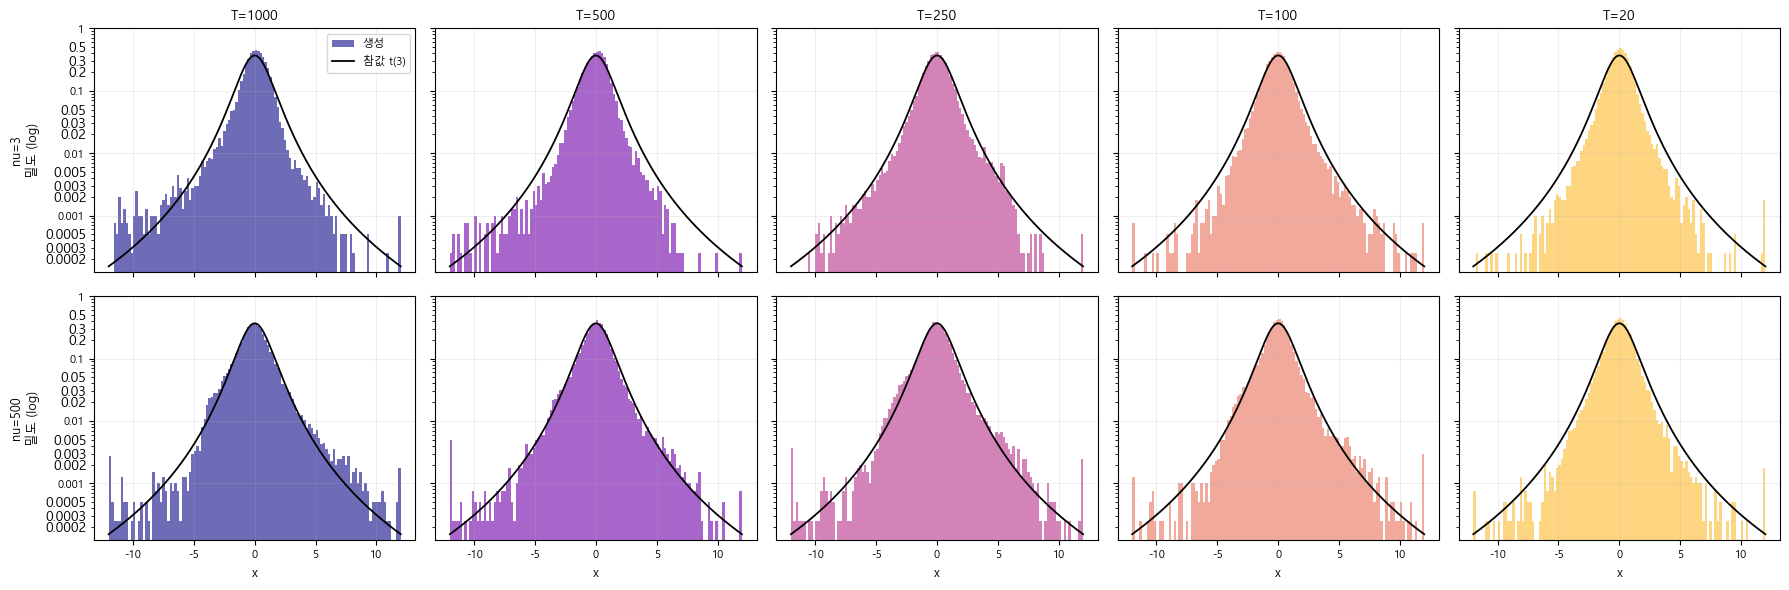

In [26]:
BINS, LIM = 120, 12.0
_grid = np.linspace(-LIM, LIM, 2000)
_floor = 1.0 / (N_SAMPLE * (2 * LIM / BINS)) / 2

fig, axes = plt.subplots(len(NU_LIST), len(T_LIST),
                         figsize=(3.6 * len(T_LIST), 3.0 * len(NU_LIST)),
                         squeeze=False, sharey=True, sharex=True)
for r_, nu in enumerate(NU_LIST):
    for c_, T in enumerate(T_LIST):
        ax = axes[r_][c_]
        g = GEN[(nu, T, SEEDS[0])]
        ax.hist(np.clip(g, -LIM, LIM), bins=BINS, range=(-LIM, LIM),
                density=True, alpha=0.6, color=COLT[T], label="생성")
        ax.plot(_grid, stats.t.pdf(_grid, NU_DATA), "k-", lw=1.3,
                label=f"참값 t({NU_DATA:g})")
        ax.set_yscale("log")
        ax.set_ylim(_floor, 1)
        plain_ticks(ax)
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.2)
        if r_ == 0:
            ax.set_title(f"T={T}", fontsize=10)
        if c_ == 0:
            ax.set_ylabel(f"nu={nu:g}{chr(10)}밀도 (log)", fontsize=9)
            if r_ == 0:
                ax.legend(fontsize=8)
        if r_ == len(NU_LIST) - 1:
            ax.set_xlabel("x", fontsize=9)
fig.tight_layout()
plt.show()